WTI WEEKLY DIRECTION MODEL — OPTUNA PARAMS

Resampling to weekly (Friday close)...
Raw weekly data: 1113 weeks (2005-01-07 -> 2026-05-01)
Computing EMD (expanding window, 1112 weeks)...
IMFs computed: 4  |  NaNs in IMF_1: 53 (first 52 weeks discarded)
Available data: 1060 weeks (2006-01-13 -> 2026-05-01)

Split preview (lag=52):
  Train: 852 weeks  (2007-01-12 -> 2023-05-05)
  Val:   52 weeks  (2023-05-12 -> 2024-05-03)
  Test:  104 weeks   (2024-05-10 -> 2026-05-01)
  Train UP: 462  DOWN: 390  scale_pos_weight: 0.84

=== LAG SELECTION BY WALK-FORWARD CV (Optuna params) ===
  Lag |  Features |   Mean F1 CV
--------------------------------
    4  |        56 |       0.5277
   12  |       144 |       0.5146
   24  |       276 |       0.5239
   52  |       584 |       0.5294

-> Best lag by CV: 52 (F1_cv=0.5294)

=== LAG CONFIGURATION COMPARISON ===
 Lags |  Features |    Acc |     F1 |    AUC
--------------------------------------------
    4  |        56 | 0.4712 | 0.5299 | 0.4556
   12

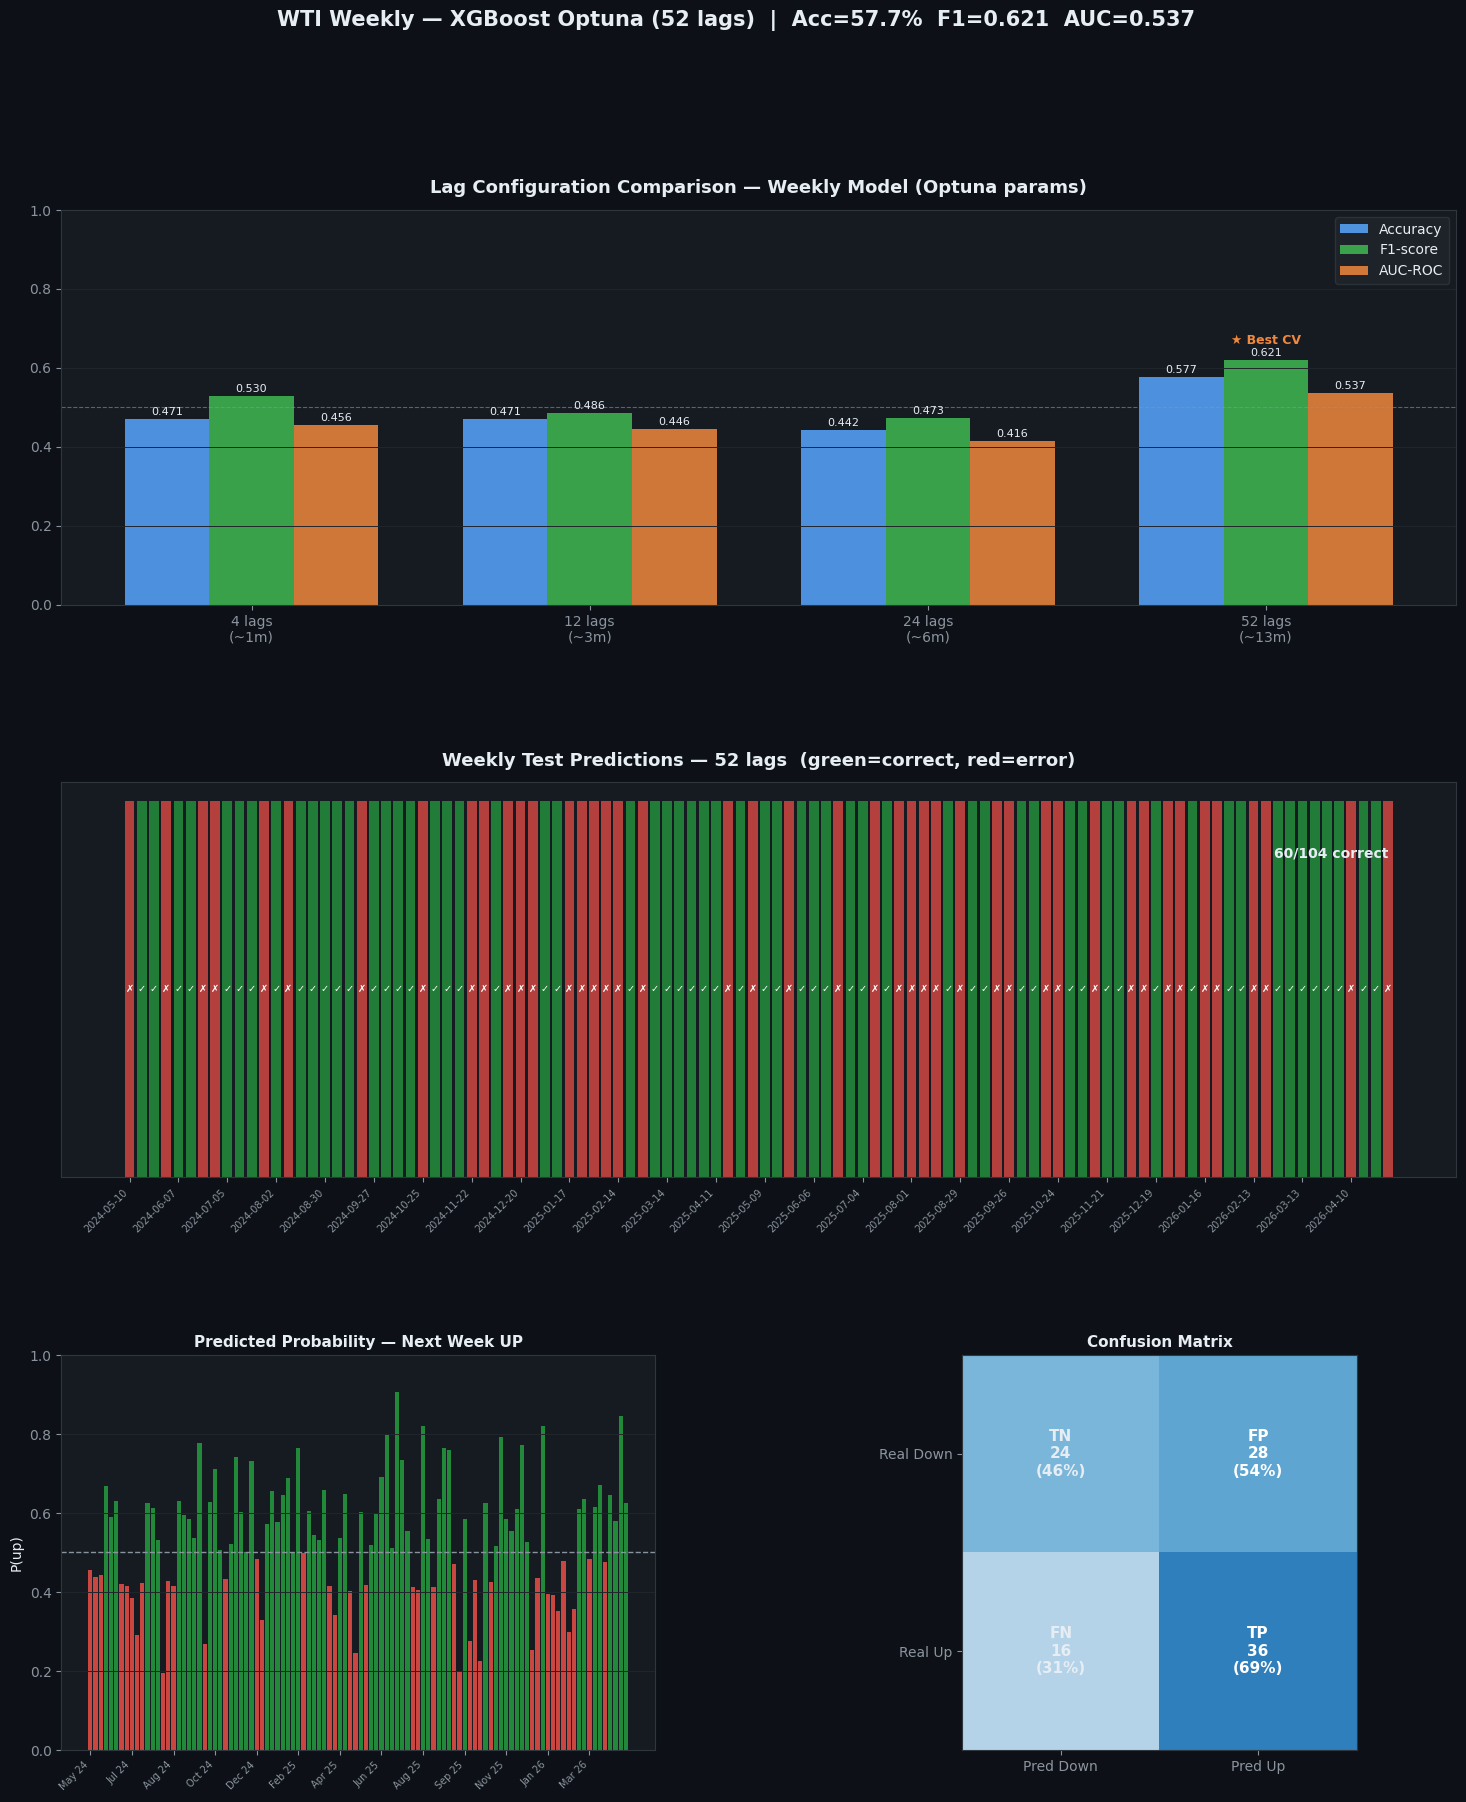

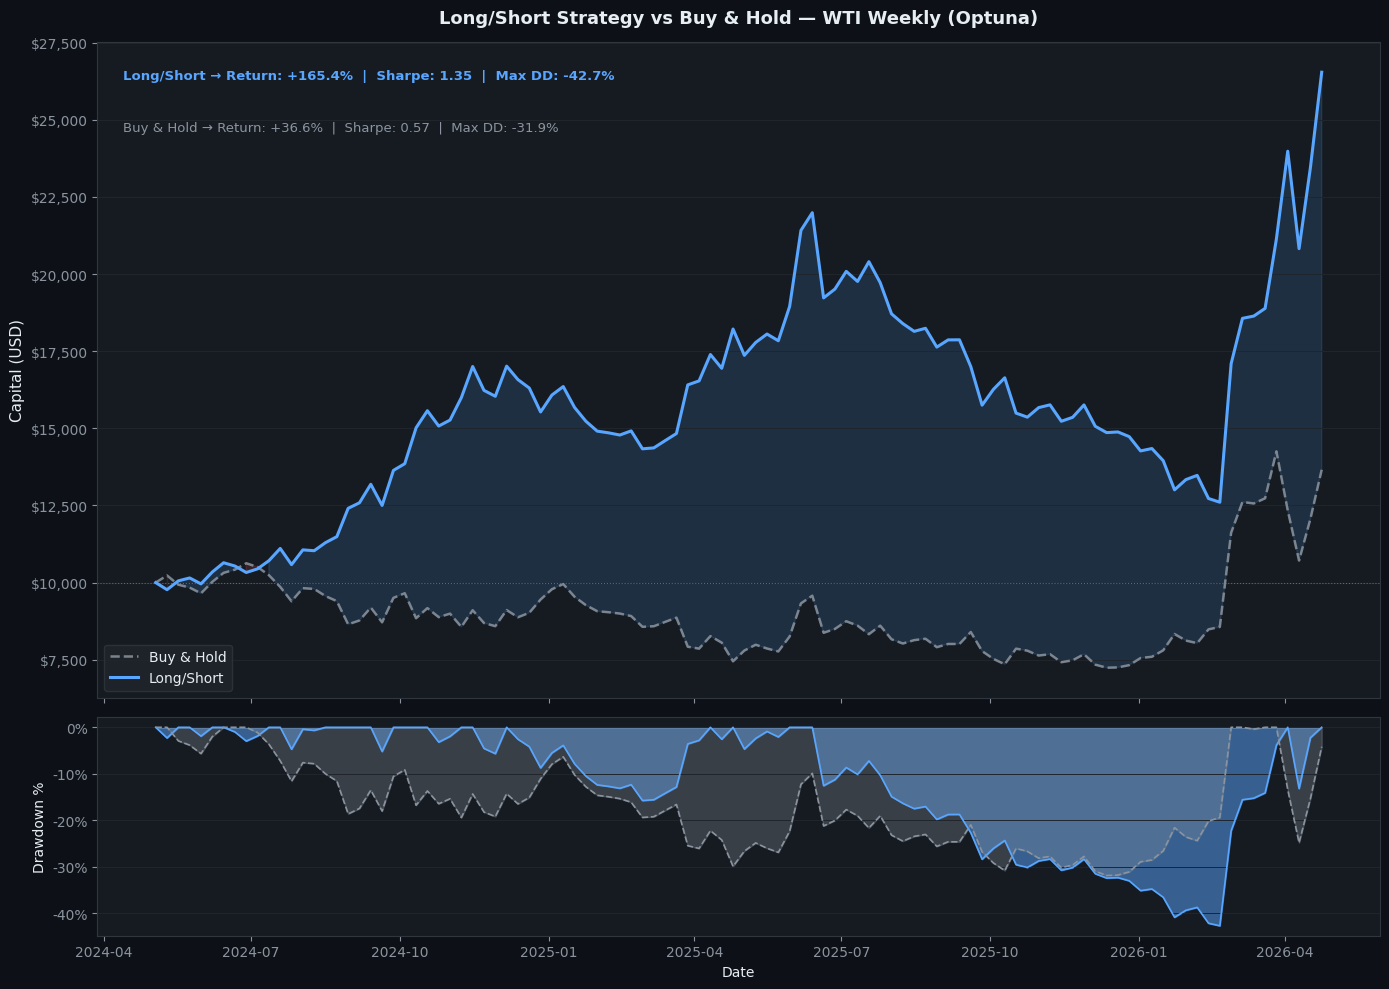


=== NEXT WEEK PREDICTION ===
Last week with data:  2026-05-01
Prediction for week:  2026-05-08
Predicted direction:  UP
Probability up:       62.5%
Probability down:     37.5%

=== SHAP ANALYSIS — XGBoost Weekly (Optuna) ===
Computing SHAP values on test set...

Features with SHAP > 0:  416 / 584
Features with SHAP ≈ 0:  168 / 584

Rank   Feature                           Mean |SHAP|    Cum %
--------------------------------------------------------------
1      IMF_1_lag7                             0.1332     1.7%
2      SSE_ret_lag24                          0.1130     3.2%
3      SSE_ret_lag41                          0.1074     4.6%
4      SP500_ret_lag13                        0.0846     5.7%
5      SP500_ret_lag42                        0.0787     6.7%
6      EPU_US_logdiff_lag41                   0.0774     7.7%
7      EPU_US_logdiff_lag25                   0.0768     8.7%
8      IMF_2_lag49                            0.0737     9.7%
9      SSE_ret_lag43                        

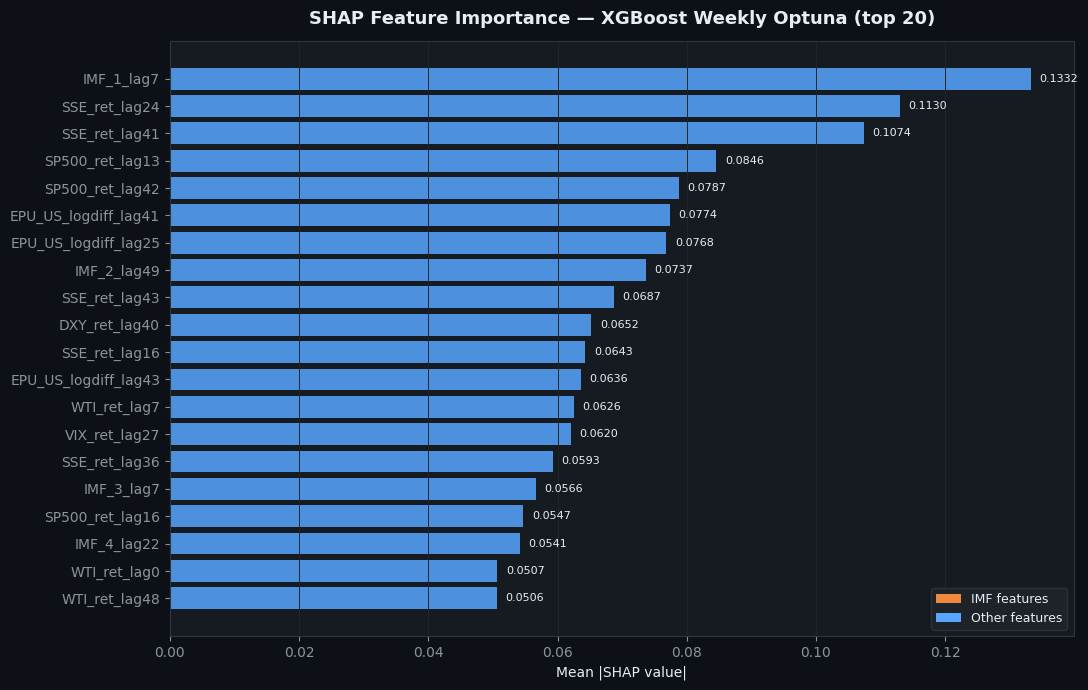


=== MUTUAL INFORMATION ANALYSIS ===
Computing MI on train set...

Top 20 features by MI:
Rank   Feature                            MI score   MI norm
------------------------------------------------------------
1      T10Y_diff_lag17                      0.0550    1.000
2      VIX_ret_lag19                        0.0477    0.868
3      IMF_2_lag11                          0.0426    0.774
4      IMF_4_lag37                          0.0408    0.742
5      SP500_ret_lag19                      0.0392    0.713
6      IMF_2_lag29                          0.0382    0.696
7      IMF_3_lag41                          0.0350    0.636
8      IMF_4_lag50                          0.0344    0.626
9      IMF_2_lag4                           0.0330    0.600
10     VIX_ret_lag36                        0.0329    0.599
11     IMF_3_lag19                          0.0327    0.594
12     T10Y_diff_lag21                      0.0313    0.570
13     SSE_ret_lag4                         0.0311    0.567
14     D

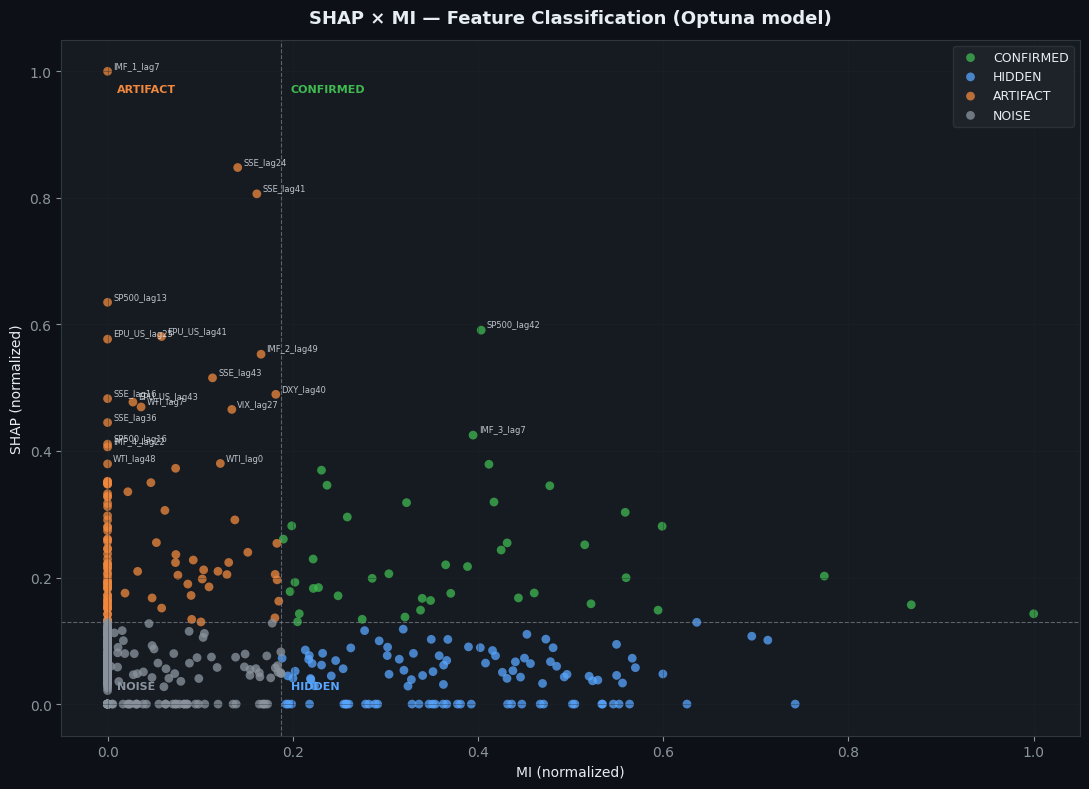


=== SHAP × MI SUMMARY ===
Thresholds: SHAP_norm > 0.130 | MI_norm > 0.188
  CONFIRMED   :   42 features
  HIDDEN      :  104 features
  ARTIFACT    :  104 features
  NOISE       :  334 features

CONFIRMED por grupo: {'VIX': np.int64(8), 'IMF_2': np.int64(6), 'T10Y': np.int64(5), 'IMF_3': np.int64(4), 'SP500': np.int64(4), 'EPU_US': np.int64(4), 'IMF_4': np.int64(3), 'IMF_1': np.int64(2), 'DXY': np.int64(2), 'WTI_ret': np.int64(2), 'SSE': np.int64(2)}
HIDDEN por grupo:    {'IMF_3': np.int64(15), 'WTI_ret': np.int64(13), 'DXY': np.int64(12), 'EPU_US': np.int64(10), 'T10Y': np.int64(9), 'IMF_4': np.int64(9), 'VIX': np.int64(8), 'SSE': np.int64(8), 'IMF_2': np.int64(7), 'IMF_1': np.int64(7), 'SP500': np.int64(5), 'BB_pct_w': np.int64(1)}

FINAL SUMMARY — WTI WEEKLY MODEL (OPTUNA)
Frequency:       Weekly (Friday close)
Best lag CV:     52 weeks (~13 months)
Features:        584
Train obs:       852
Ratio obs/feat:  1.46
Test obs:        104 weeks

Hyperparameters (Optuna):
  n_estimators  

In [ ]:
# -*- coding: utf-8 -*-
"""Modelo semanal.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1e7peMa97Ss7WaENfWKE9W1mdOSeoC4lO
"""

# -*- coding: utf-8 -*-
"""
WTI Crude Oil Weekly Direction Prediction — XGBoost (Optuna params)
Target: Will WTI price go UP (1) or DOWN (0) next week?
Features: lagged weekly financial variables + technical indicators + EMD
Frequency: Weekly (Friday close)
Main model uses Optuna-tuned hyperparameters directly.
"""

# =========================
# 0. IMPORTS & INSTALL
# =========================
import subprocess
subprocess.run(["pip", "install", "EMD-signal", "shap", "optuna", "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
import itertools
warnings.filterwarnings("ignore")

import yfinance as yf
from pandas_datareader import data as pdr
from PyEMD import EMD

import shap
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

# =========================
# COLOR PALETTE
# =========================
COLOR_BG    = "white"
COLOR_AX    = "white"
COLOR_GRID  = "white"
COLOR_TEXT  = "white"
COLOR_MUT   = "#555555"
COLOR_GREEN = "#3fb950"
COLOR_GRAY  = "#555555"
COLOR_BLUE  = "#58a6ff"
COLOR_RED   = "#f85149"
COLOR_AMBER = "#f0883e"
COLOR_UP    = "#26a641"
COLOR_DOWN  = "#f85149"

plt.rcParams.update({
    "text.color":       COLOR_TEXT,
    "axes.labelcolor":  COLOR_TEXT,
    "xtick.color":      COLOR_MUT,
    "ytick.color":      COLOR_MUT,
    "figure.facecolor": COLOR_BG,
    "axes.facecolor":   COLOR_AX,
})

# =========================
# 1. GLOBAL PARAMETERS
# =========================
START        = "2005-01-01"
END          = "2026-04-30"
TEST_WEEKS   = 104
VAL_WEEKS    = 52
LAG_OPTIONS  = [4, 12, 24, 52]

# ── OPTUNA PARAMS (from previous run) ────────────────────────
# These replace BASE_PARAMS as the main model configuration
OPTUNA_PARAMS = dict(
    n_estimators      = 175,
    max_depth         = 4,
    learning_rate     = 0.07760748382919296,
    subsample         = 0.7509740670797509,
    colsample_bytree  = 0.7745994516724066,
    reg_alpha         = 1.6452335461547967,
    reg_lambda        = 1.8345951129118618,
    min_child_weight  = 12,
    gamma             = 0.7084539579740855,
    random_state      = SEED,
    verbosity         = 0,
    eval_metric       = "logloss",
)

# =========================
# 2. DATA DOWNLOAD
# =========================
print("=" * 60)
print("WTI WEEKLY DIRECTION MODEL — OPTUNA PARAMS")
print("=" * 60)

def download_yahoo(ticker, col_name, start, end):
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        s = raw["Close"].iloc[:, 0]
    else:
        s = raw["Close"]
    s = pd.Series(s.dropna())
    s.name = col_name
    return s

print("\nDownloading market data (Yahoo Finance)...")
wti   = download_yahoo("CL=F",     "WTI",   START, END)
sp500 = download_yahoo("^GSPC",    "SP500", START, END)
dxy   = download_yahoo("DX-Y.NYB", "DXY",   START, END)
vix   = download_yahoo("^VIX",     "VIX",   START, END)
sse   = download_yahoo("000001.SS","SSE",   START, END)

print("Downloading FRED data...")
t10y   = pdr.DataReader("DGS10",      "fred", START, END)
epu_us = pdr.DataReader("USEPUINDXD", "fred", START, END)

t10y.columns   = ["T10Y"]
epu_us.columns = ["EPU_US"]

for obj in [t10y, epu_us]:
    obj.index = pd.to_datetime(obj.index)

# =========================
# 3. WEEKLY RESAMPLING
# =========================
print("Resampling to weekly (Friday close)...")

wti_w   = wti.resample("W-FRI").last()
sp500_w = sp500.resample("W-FRI").last()
dxy_w   = dxy.resample("W-FRI").last()
vix_w   = vix.resample("W-FRI").last()
sse_w   = sse.resample("W-FRI").last()
t10y_w   = t10y.resample("W-FRI").last().ffill()
epu_us_w = epu_us.resample("W-FRI").last().ffill()

for s in [wti_w, sp500_w, dxy_w, vix_w, sse_w]:
    s.index = s.index.normalize()
for df_obj in [t10y_w, epu_us_w]:
    df_obj.index = df_obj.index.normalize()

df = pd.concat([
    wti_w.rename("WTI"),
    sp500_w.rename("SP500"),
    dxy_w.rename("DXY"),
    vix_w.rename("VIX"),
    sse_w.rename("SSE"),
    t10y_w,
    epu_us_w,
], axis=1)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.ffill(limit=3).dropna()

print(f"Raw weekly data: {len(df)} weeks "
      f"({df.index[0].date()} -> {df.index[-1].date()})")

# =========================
# 4. FEATURE ENGINEERING
# =========================
df_feat = pd.DataFrame(index=df.index)

df_feat["WTI_ret"]        = np.log(df["WTI"]).diff()
df_feat["SP500_ret"]      = np.log(df["SP500"]).diff()
df_feat["DXY_ret"]        = np.log(df["DXY"]).diff()
df_feat["VIX_ret"]        = np.log(df["VIX"]).diff()
df_feat["SSE_ret"]        = np.log(df["SSE"]).diff()
df_feat["T10Y_diff"]      = df["T10Y"].diff()
df_feat["EPU_US_logdiff"] = np.log(df["EPU_US"].replace(0, np.nan)).diff()

ema12 = df["WTI"].ewm(span=12, adjust=False).mean()
ema24 = df["WTI"].ewm(span=24, adjust=False).mean()
df_feat["EMA_12w"] = ema12 / df["WTI"] - 1
df_feat["EMA_24w"] = ema24 / df["WTI"] - 1
df_feat["MACD_w"]  = (ema12 - ema24) / df["WTI"]

delta = df["WTI"].diff()
gain  = delta.clip(lower=0).ewm(span=6, adjust=False).mean()
loss  = (-delta.clip(upper=0)).ewm(span=6, adjust=False).mean()
df_feat["RSI_6w"] = (100 - (100 / (1 + gain / (loss + 1e-10)))) / 100

bb_mid   = df["WTI"].rolling(12).mean()
bb_std   = df["WTI"].rolling(12).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std
df_feat["BB_pct_w"] = (df["WTI"] - bb_lower) / (bb_upper - bb_lower + 1e-10)

# EMD — expanding window, no lookahead
N_IMFS  = 4
MIN_OBS = 52

imf_data = {f"IMF_{i+1}": np.full(len(df_feat), np.nan) for i in range(N_IMFS)}
wti_ret_clean = df_feat["WTI_ret"].dropna()
indices       = wti_ret_clean.index
values        = wti_ret_clean.values

print(f"Computing EMD (expanding window, {len(values)} weeks)...")
for t in range(MIN_OBS, len(values)):
    serie = values[:t+1]
    try:
        emd  = EMD()
        imfs = emd.emd(serie, max_imf=N_IMFS)
        for i in range(min(N_IMFS, imfs.shape[0])):
            pos = df_feat.index.get_loc(indices[t])
            imf_data[f"IMF_{i+1}"][pos] = imfs[i, -1]
    except Exception:
        pass

for i in range(N_IMFS):
    df_feat[f"IMF_{i+1}"] = imf_data[f"IMF_{i+1}"]

print(f"IMFs computed: {N_IMFS}  |  "
      f"NaNs in IMF_1: {df_feat['IMF_1'].isna().sum()} "
      f"(first {MIN_OBS} weeks discarded)")

df_feat["target"] = (df_feat["WTI_ret"].shift(-1) > 0).astype(int)
df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Available data: {len(df_feat)} weeks "
      f"({df_feat.index[0].date()} -> {df_feat.index[-1].date()})")

LAG0_VARS = [
    "WTI_ret", "SP500_ret", "DXY_ret", "VIX_ret",
    "SSE_ret", "T10Y_diff", "EPU_US_logdiff"
]
LAG1_VARS = ["IMF_1", "IMF_2", "IMF_3", "IMF_4"]
TECH_VARS = ["EMA_12w", "EMA_24w", "MACD_w", "RSI_6w", "BB_pct_w"]

# =========================
# 5. FEATURE MATRIX
# =========================
def build_features(df_feat, max_lag, exclude=None):
    exclude = exclude or []
    frames  = []
    for var in LAG0_VARS:
        for lag in range(0, max_lag + 1):
            col_name = f"{var}_lag{lag}"
            if col_name in exclude:
                continue
            col = df_feat[var].shift(lag)
            col.name = col_name
            frames.append(col)
    for var in LAG1_VARS:
        for lag in range(1, max_lag + 1):
            col_name = f"{var}_lag{lag}"
            if col_name in exclude:
                continue
            col = df_feat[var].shift(lag)
            col.name = col_name
            frames.append(col)
    for var in TECH_VARS:
        if var not in exclude:
          frames.append(df_feat[var])
    X = pd.concat(frames, axis=1)
    y = df_feat["target"]
    combined = pd.concat([X, y], axis=1).dropna()
    return combined.drop("target", axis=1), combined["target"]

# =========================
# 6. TEMPORAL SPLIT
# =========================
def get_splits(X, y):
    n    = len(X)
    n_tr = n - TEST_WEEKS - VAL_WEEKS
    return (X.iloc[:n_tr],               y.iloc[:n_tr],
            X.iloc[n_tr:n_tr+VAL_WEEKS], y.iloc[n_tr:n_tr+VAL_WEEKS],
            X.iloc[n_tr+VAL_WEEKS:],     y.iloc[n_tr+VAL_WEEKS:])

X_tmp, y_tmp = build_features(df_feat, 52)
X_tr, y_tr, _, _, _, _ = get_splits(X_tmp, y_tmp)
ratio = (y_tr == 0).sum() / y_tr.sum()

print(f"\nSplit preview (lag=52):")
X_tr2, y_tr2, X_val2, y_val2, X_te2, y_te2 = get_splits(X_tmp, y_tmp)
print(f"  Train: {len(X_tr2)} weeks  "
      f"({X_tr2.index[0].date()} -> {X_tr2.index[-1].date()})")
print(f"  Val:   {len(X_val2)} weeks  "
      f"({X_val2.index[0].date()} -> {X_val2.index[-1].date()})")
print(f"  Test:  {len(X_te2)} weeks   "
      f"({X_te2.index[0].date()} -> {X_te2.index[-1].date()})")
print(f"  Train UP: {y_tr2.sum()}  DOWN: {(y_tr2==0).sum()}  "
      f"scale_pos_weight: {ratio:.2f}")

# =========================
# 7. WALK-FORWARD CV — LAG SELECTION
# Uses Optuna params for lag selection
# =========================
def walk_forward_cv(df_feat, max_lag, params, n_splits=5, exclude=None):
    X, y = build_features(df_feat, max_lag, exclude=exclude)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    f1_scores = []
    for train_idx, test_idx in tscv.split(X):
        X_tr = X.iloc[train_idx]; y_tr = y.iloc[train_idx]
        X_te = X.iloc[test_idx];  y_te = y.iloc[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        r = (y_tr == 0).sum() / y_tr.sum()
        p = {**params, "scale_pos_weight": r}
        m = XGBClassifier(**p)
        m.fit(X_tr, y_tr)
        f1_scores.append(f1_score(m.predict(X_te), y_te, zero_division=0))
    return np.mean(f1_scores) if f1_scores else 0.0

print("\n=== LAG SELECTION BY WALK-FORWARD CV (Optuna params) ===")
print(f"{'Lag':>5} | {'Features':>9} | {'Mean F1 CV':>12}")
print("-" * 32)

cv_results = {}
for max_lag in LAG_OPTIONS:
    X_tmp2, _ = build_features(df_feat, max_lag)
    n_feat    = X_tmp2.shape[1]
    f1_cv     = walk_forward_cv(df_feat, max_lag,
                                {**OPTUNA_PARAMS, "scale_pos_weight": ratio})
    cv_results[max_lag] = f1_cv
    print(f"  {max_lag:>3}  | {n_feat:>9} | {f1_cv:>12.4f}")

best_lag = max(cv_results, key=cv_results.get)
print(f"\n-> Best lag by CV: {best_lag} "
      f"(F1_cv={cv_results[best_lag]:.4f})")

# =========================
# 8. LAG COMPARISON TABLE
# =========================
print(f"\n=== LAG CONFIGURATION COMPARISON ===")
print(f"{'Lags':>5} | {'Features':>9} | {'Acc':>6} | {'F1':>6} | {'AUC':>6}")
print("-" * 44)

lag_results = {}
for max_lag in LAG_OPTIONS:
    X, y = build_features(df_feat, max_lag)
    X_train, y_train, X_val, y_val, X_test, y_test = get_splits(X, y)
    r  = (y_train == 0).sum() / y_train.sum()
    m  = XGBClassifier(**{**OPTUNA_PARAMS, "scale_pos_weight": r})
    m.fit(X_train, y_train)
    yp  = m.predict(X_test)
    ypr = m.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp)
    auc = roc_auc_score(y_test, ypr)
    lag_results[max_lag] = {
        "acc": acc, "f1": f1, "auc": auc,
        "n_features": X.shape[1],
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "y_pred": yp, "y_proba": ypr, "model": m
    }
    marker = " ← best CV" if max_lag == best_lag else ""
    print(f"  {max_lag:>3}  | {X.shape[1]:>9} | "
          f"{acc:.4f} | {f1:.4f} | {auc:.4f}{marker}")

# =========================
# 9. FINAL MODEL — BEST LAG WITH OPTUNA PARAMS
# =========================
X, y = build_features(df_feat, best_lag)
X_train, y_train, X_val, y_val, X_test, y_test = get_splits(X, y)
ratio = (y_train == 0).sum() / y_train.sum()

best_model = XGBClassifier(**{**OPTUNA_PARAMS, "scale_pos_weight": ratio})
best_model.fit(X_train, y_train)

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

# Stability
print(f"\n=== STABILITY ANALYSIS ({best_lag} lags, 10 seeds) ===")
f1_seeds = []
for s in [0, 7, 13, 21, 42, 99, 123, 200, 314, 999]:
    m = XGBClassifier(**{**OPTUNA_PARAMS, "scale_pos_weight": ratio,
                         "random_state": s})
    m.fit(X_train, y_train)
    f1_seeds.append(f1_score(m.predict(X_test), y_test))

print(f"Mean F1: {np.mean(f1_seeds):.4f}")
print(f"F1 std:  {np.std(f1_seeds):.4f}")
print(f"Min/Max: {min(f1_seeds):.4f} / {max(f1_seeds):.4f}")

# =========================
# 10. DETAILED RESULTS
# =========================
print(f"\n=== DETAILED REPORT — XGBoost Weekly Optuna ({best_lag} lags) ===")
print(classification_report(y_test, y_pred,
      target_names=["Down (0)", "Up (1)"]))

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion matrix:  TN={cm[0,0]}  FP={cm[0,1]}  "
      f"FN={cm[1,0]}  TP={cm[1,1]}")

print(f"\n=== TEST PREDICTIONS ===")
print(f"{'Date':<12} | {'Real':>6} | {'Pred':>6} | "
      f"{'P(down)':>8} | {'P(up)':>8} | {'Result':>7} | Confidence")
print("-" * 75)
for date, real, pred, proba in zip(
        X_test.index, y_test.values, y_pred, y_proba):
    real_s = "UP"   if real == 1 else "DOWN"
    pred_s = "UP"   if pred == 1 else "DOWN"
    res    = "OK"   if real == pred else "ERROR"
    conf   = max(proba, 1 - proba)
    print(f"{date.strftime('%Y-%m-%d'):<12} | {real_s:>6} | {pred_s:>6} | "
          f"{1-proba:>7.1%} | {proba:>7.1%} | {res:>7} | "
          f"{conf:.1%} {'U' if proba > 0.5 else 'D'}")

print(f"\n=== CONFIDENCE LEVEL ANALYSIS ===")
confidences = np.maximum(y_proba, 1 - y_proba)
print(f"{'Threshold':>10} | {'Predictions':>13} | "
      f"{'Acc':>6} | {'F1':>6} | {'Coverage':>10}")
print("-" * 55)
for u in [0.50, 0.53, 0.55, 0.58, 0.60]:
    mask_c = confidences >= u
    if mask_c.sum() == 0:
        continue
    acc_u = accuracy_score(y_test[mask_c], y_pred[mask_c])
    f1_u  = f1_score(y_test[mask_c], y_pred[mask_c], zero_division=0)
    print(f"{u:>10.0%} | {mask_c.sum():>13} | "
          f"{acc_u:.4f} | {f1_u:.4f} | {mask_c.sum()/len(y_test):>9.1%}")

print(f"\n=== ERROR ANALYSIS BY MAGNITUDE ===")
errors_mask  = y_test.values != y_pred
correct_mask = ~errors_mask
wti_rets = np.array([df_feat.loc[d, "WTI_ret"]
                     for d in X_test.index if d in df_feat.index])
changes  = (np.exp(wti_rets) - 1) * 100
if len(wti_rets) == len(errors_mask):
    err_changes = np.abs(changes[errors_mask])
    ok_changes  = np.abs(changes[correct_mask])
    print(f"Mean |change| on ERRORS:   {err_changes.mean():.2f}%")
    print(f"Mean |change| on CORRECT:  {ok_changes.mean():.2f}%")
    print(f"Errors with |change| < 1%: "
          f"{(err_changes < 1).sum()} / {errors_mask.sum()}")
    print(f"Errors with |change| > 3%: "
          f"{(err_changes > 3).sum()} / {errors_mask.sum()}")

# =========================
# 11. BENCHMARK
# =========================
print(f"\n=== MODEL BENCHMARK ({best_lag} lags) ===")
print(f"{'Model':<15} | {'Acc':>6} | {'F1':>6} | {'AUC':>6}")
print("-" * 38)

models_bench = {
    "XGBoost(Opt)": XGBClassifier(**{**OPTUNA_PARAMS,
                                      "scale_pos_weight": ratio}),
    "LightGBM":     LGBMClassifier(n_estimators=200, max_depth=4,
                                    learning_rate=0.08, subsample=0.75,
                                    colsample_bytree=0.78, reg_alpha=1.6,
                                    reg_lambda=1.8, min_child_samples=12,
                                    scale_pos_weight=ratio,
                                    random_state=SEED, verbose=-1),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=5,
                                            min_samples_leaf=5,
                                            class_weight="balanced",
                                            random_state=SEED),
    "LDA":          LinearDiscriminantAnalysis(),
    "NaiveBayes":   GaussianNB(),
    "LogisticReg":  LogisticRegression(C=0.1, class_weight="balanced",
                                        max_iter=1000, random_state=SEED),
}

bench_results = {}
for name, clf in models_bench.items():
    clf.fit(X_train, y_train)
    yp  = clf.predict(X_test)
    ypr = clf.predict_proba(X_test)[:, 1]
    r   = {"acc": accuracy_score(y_test, yp),
           "f1":  f1_score(y_test, yp),
           "auc": roc_auc_score(y_test, ypr),
           "model": clf}
    bench_results[name] = r
    print(f"{name:<15} | {r['acc']:.4f} | {r['f1']:.4f} | {r['auc']:.4f}")

# =========================
# 12. TRADING SIMULATION
# =========================
INITIAL_CAPITAL = 10_000

wti_prices = df["WTI"].reindex(X_test.index).ffill()
real_ret_w = wti_prices.pct_change().shift(-1).reindex(X_test.index)
mask       = real_ret_w.notna()
dates      = X_test.index[mask]
ret        = real_ret_w[mask].values
pred_s     = y_pred[mask.values]
n          = len(ret)

def compute_metrics(cap):
    cap    = np.array(cap)
    rets   = np.diff(cap) / cap[:-1]
    total  = (cap[-1] / cap[0] - 1) * 100
    sharpe = (rets.mean() / (rets.std() + 1e-10)) * np.sqrt(52)
    dd     = ((cap - np.maximum.accumulate(cap)) /
               np.maximum.accumulate(cap)).min() * 100
    return {"total": total, "sharpe": sharpe, "dd": dd}

cap_bh = [INITIAL_CAPITAL]; cap_bo = [INITIAL_CAPITAL]; cap_ls = [INITIAL_CAPITAL]
for r, p in zip(ret, pred_s):
    cap_bh.append(cap_bh[-1] * (1 + r))
    cap_bo.append(cap_bo[-1] * (1 + r) if p == 1 else cap_bo[-1])
    cap_ls.append(cap_ls[-1] * (1 + r) if p == 1 else cap_ls[-1] * (1 - r))

met_bh = compute_metrics(cap_bh)
met_bo = compute_metrics(cap_bo)
met_ls = compute_metrics(cap_ls)

print(f"\n{'='*60}")
print("STRATEGY SUMMARY — WTI Weekly Optuna (test period)")
print(f"{'='*60}")
print(f"Period: {dates[0].strftime('%Y-%m-%d')} -> "
      f"{dates[-1].strftime('%Y-%m-%d')}  ({n} weeks)")
print(f"Correct: {int((y_test.values[mask.values] == pred_s).sum())}/{n}")
print("-"*60)
print(f"{'Metric':<22} {'Buy&Hold':>10} {'Buy-Only':>11} {'Long/Short':>11}")
print("-"*60)
print(f"{'Total Return (%)':<22} {met_bh['total']:>9.1f}% "
      f"{met_bo['total']:>10.1f}% {met_ls['total']:>10.1f}%")
print(f"{'Sharpe (annualized)':<22} {met_bh['sharpe']:>10.2f} "
      f"{met_bo['sharpe']:>11.2f} {met_ls['sharpe']:>11.2f}")
print(f"{'Max Drawdown (%)':<22} {met_bh['dd']:>9.1f}% "
      f"{met_bo['dd']:>10.1f}% {met_ls['dd']:>10.1f}%")
print(f"{'Final Capital ($)':<22} {cap_bh[-1]:>10,.0f} "
      f"{cap_bo[-1]:>11,.0f} {cap_ls[-1]:>11,.0f}")
print("="*60)

# =========================
# 13. VISUALIZATIONS
# =========================
fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor(COLOR_BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(COLOR_AX)
lags_list = list(lag_results.keys())
accs = [lag_results[l]["acc"] for l in lags_list]
f1s  = [lag_results[l]["f1"]  for l in lags_list]
aucs = [lag_results[l]["auc"] for l in lags_list]
x    = np.arange(len(lags_list)); w = 0.25
b1 = ax1.bar(x-w, accs, w, label="Accuracy", color=COLOR_BLUE,  alpha=0.85)
b2 = ax1.bar(x,   f1s,  w, label="F1-score", color=COLOR_GREEN, alpha=0.85)
b3 = ax1.bar(x+w, aucs, w, label="AUC-ROC",  color=COLOR_AMBER, alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.3f}", ha="center", va="bottom",
                 fontsize=8, color=COLOR_TEXT)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{l} lags\n(~{l//4}m)" for l in lags_list])
ax1.set_ylim(0, 1.0)
ax1.axhline(0.5, color=COLOR_MUT, linestyle="--", linewidth=0.8, alpha=0.6)
ax1.set_title("Lag Configuration Comparison — Weekly Model (Optuna params)",
              color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=12)
ax1.legend(facecolor="white", edgecolor="#30363d", labelcolor=COLOR_TEXT)
ax1.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax1.spines[["top","right","left","bottom"]].set_color("#30363d")
best_x = lags_list.index(best_lag)
ax1.annotate("★ Best CV", xy=(best_x, f1s[best_x] + 0.04),
             ha="center", color=COLOR_AMBER, fontsize=9, fontweight="bold")

ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor(COLOR_AX)
for i, (date, real, pred) in enumerate(zip(
        X_test.index, y_test.values, y_pred)):
    color = COLOR_UP if real == pred else COLOR_DOWN
    ax2.bar(i, 1, color=color, alpha=0.7, width=0.8)
    ax2.text(i, 0.5, "✓" if real == pred else "✗",
             ha="center", va="center", fontsize=7,
             color="white", fontweight="bold")
ax2.set_xticks(range(0, len(X_test.index), 4))
ax2.set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in X_test.index[::4]],
    rotation=45, ha="right", fontsize=7)
ax2.set_yticks([])
n_correct = int((y_test.values == y_pred).sum())
ax2.text(len(X_test.index) - 1, 0.85,
         f"{n_correct}/{len(y_test)} correct",
         ha="right", color=COLOR_TEXT, fontsize=10, fontweight="bold")
ax2.set_title(f"Weekly Test Predictions — {best_lag} lags  "
              f"(green=correct, red=error)",
              color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=12)
ax2.spines[["top","right","left","bottom"]].set_color("#30363d")

ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor(COLOR_AX)
colors_prob = [COLOR_UP if p >= 0.5 else COLOR_DOWN for p in y_proba]
ax3.bar(range(len(y_proba)), y_proba, color=colors_prob, alpha=0.8, width=0.8)
ax3.axhline(0.5, color=COLOR_MUT, linestyle="--", linewidth=1)
ax3.set_xticks(range(0, len(X_test.index), 8))
ax3.set_xticklabels(
    [d.strftime("%b %y") for d in X_test.index[::8]],
    rotation=45, ha="right", fontsize=7)
ax3.set_ylim(0, 1)
ax3.set_ylabel("P(up)", color=COLOR_TEXT)
ax3.set_title("Predicted Probability — Next Week UP",
              color=COLOR_TEXT, fontsize=11, fontweight="bold")
ax3.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax3.spines[["top","right","left","bottom"]].set_color("#30363d")

ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor(COLOR_AX)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ax4.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f"{labels[i][j]}\n{cm[i,j]}\n({cm_norm[i,j]:.0%})",
                 ha="center", va="center", fontsize=11,
                 color="white" if cm_norm[i,j] > 0.5 else COLOR_TEXT,
                 fontweight="bold")
ax4.set_xticks([0, 1]); ax4.set_yticks([0, 1])
ax4.set_xticklabels(["Pred Down", "Pred Up"])
ax4.set_yticklabels(["Real Down", "Real Up"])
ax4.set_title("Confusion Matrix", color=COLOR_TEXT,
              fontsize=11, fontweight="bold")
ax4.spines[["top","right","left","bottom"]].set_color("#30363d")

fig.suptitle(
    f"WTI Weekly — XGBoost Optuna ({best_lag} lags)  |  "
    f"Acc={acc:.1%}  F1={f1:.3f}  AUC={auc:.3f}",
    color=COLOR_TEXT, fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout(); plt.show()

# Trading chart
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10),
                            gridspec_kw={"height_ratios": [3, 1]},
                            facecolor=COLOR_BG)
fig2.subplots_adjust(hspace=0.08)
dates_plot = pd.DatetimeIndex(
    [dates[0] - pd.DateOffset(weeks=1)] + list(dates))
cap_bh_arr = np.array(cap_bh); cap_ls_arr = np.array(cap_ls)

ax_t = axes2[0]; ax_t.set_facecolor(COLOR_AX)
ax_t.plot(dates_plot, cap_bh_arr, color=COLOR_GRAY, linewidth=1.8,
          linestyle="--", label="Buy & Hold", alpha=0.85)
ax_t.plot(dates_plot, cap_ls_arr, color=COLOR_BLUE, linewidth=2.2,
          label="Long/Short", zorder=3)
ax_t.fill_between(dates_plot, cap_ls_arr, cap_bh_arr,
                  where=(cap_ls_arr >= cap_bh_arr), alpha=0.15, color=COLOR_BLUE)
ax_t.fill_between(dates_plot, cap_ls_arr, cap_bh_arr,
                  where=(cap_ls_arr < cap_bh_arr), alpha=0.15, color=COLOR_RED)
ax_t.axhline(INITIAL_CAPITAL, color=COLOR_MUT, linewidth=0.8,
             linestyle=":", alpha=0.6)
ax_t.text(0.02, 0.96,
          f"Long/Short → Return: {met_ls['total']:+.1f}%  |  "
          f"Sharpe: {met_ls['sharpe']:.2f}  |  "
          f"Max DD: {met_ls['dd']:.1f}%",
          transform=ax_t.transAxes, fontsize=9.5,
          color=COLOR_BLUE, va="top", fontweight="bold")
ax_t.text(0.02, 0.88,
          f"Buy & Hold → Return: {met_bh['total']:+.1f}%  |  "
          f"Sharpe: {met_bh['sharpe']:.2f}  |  "
          f"Max DD: {met_bh['dd']:.1f}%",
          transform=ax_t.transAxes, fontsize=9.5,
          color=COLOR_GRAY, va="top")
ax_t.set_ylabel("Capital (USD)", color=COLOR_TEXT, fontsize=11)
ax_t.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax_t.legend(facecolor="white", edgecolor="#30363d",
            labelcolor=COLOR_TEXT, fontsize=10)
ax_t.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax_t.spines[["top","right","left","bottom"]].set_color("#30363d")
ax_t.set_xticklabels([])
ax_t.set_title("Long/Short Strategy vs Buy & Hold — WTI Weekly (Optuna)",
               color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=14)

dd_ls = ((cap_ls_arr - np.maximum.accumulate(cap_ls_arr)) /
          np.maximum.accumulate(cap_ls_arr))
dd_bh = ((cap_bh_arr - np.maximum.accumulate(cap_bh_arr)) /
          np.maximum.accumulate(cap_bh_arr))
ax_dd = axes2[1]; ax_dd.set_facecolor(COLOR_AX)
ax_dd.fill_between(dates_plot, dd_ls * 100, color=COLOR_BLUE, alpha=0.5)
ax_dd.fill_between(dates_plot, dd_bh * 100, color=COLOR_GRAY, alpha=0.3)
ax_dd.plot(dates_plot, dd_ls * 100, color=COLOR_BLUE, linewidth=1.2)
ax_dd.plot(dates_plot, dd_bh * 100, color=COLOR_GRAY,
           linewidth=1.2, linestyle="--")
ax_dd.set_ylabel("Drawdown %", color=COLOR_TEXT, fontsize=10)
ax_dd.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax_dd.grid(axis="y", color=COLOR_GRID, linewidth=0.7)
ax_dd.spines[["top","right","left","bottom"]].set_color("#30363d")
ax_dd.set_xlabel("Date", color=COLOR_TEXT, fontsize=10)
plt.tight_layout(); plt.show()

# =========================
# 14. NEXT WEEK PREDICTION
# =========================
X_all, y_all  = build_features(df_feat, best_lag)
last_features = X_all.iloc[[-1]]
next_pred     = best_model.predict(last_features)[0]
next_proba    = best_model.predict_proba(last_features)[0]
last_date     = X_all.index[-1]
next_week     = last_date + pd.DateOffset(weeks=1)

print(f"\n=== NEXT WEEK PREDICTION ===")
print(f"Last week with data:  {last_date.strftime('%Y-%m-%d')}")
print(f"Prediction for week:  {next_week.strftime('%Y-%m-%d')}")
print(f"Predicted direction:  {'UP' if next_pred == 1 else 'DOWN'}")
print(f"Probability up:       {next_proba[1]:.1%}")
print(f"Probability down:     {next_proba[0]:.1%}")

# =========================
# 15. SHAP ANALYSIS
# =========================
print(f"\n=== SHAP ANALYSIS — XGBoost Weekly (Optuna) ===")
print("Computing SHAP values on test set...")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature":   X_test.columns,
    "mean_shap": mean_abs_shap
}).sort_values("mean_shap", ascending=False).reset_index(drop=True)

active = shap_df[shap_df["mean_shap"] > 1e-6]
print(f"\nFeatures with SHAP > 0:  {len(active)} / {len(shap_df)}")
print(f"Features with SHAP ≈ 0:  {len(shap_df) - len(active)} / {len(shap_df)}")

print(f"\n{'Rank':<6} {'Feature':<32} {'Mean |SHAP|':>12} {'Cum %':>8}")
print("-" * 62)
cumsum = 0; total = shap_df["mean_shap"].sum()
for i, row in active.head(25).iterrows():
    cumsum += row["mean_shap"]
    pct     = cumsum / total * 100
    print(f"{i+1:<6} {row['feature']:<32} "
          f"{row['mean_shap']:>12.4f} {pct:>7.1f}%")

def get_group(feat_name):
    bases = ["IMF_1","IMF_2","IMF_3","IMF_4",
             "EPU_US","T10Y","SP500","WTI_ret","VIX",
             "BRENT","DXY","SSE",
             "EMA_12w","EMA_24w","MACD_w","RSI_6w","BB_pct_w"]
    for b in bases:
        if feat_name.startswith(b):
            return b
    return feat_name

shap_df["group"] = shap_df["feature"].apply(get_group)
shap_df["group"] = shap_df["group"].replace(
    {"IMF_1":"IMF","IMF_2":"IMF","IMF_3":"IMF","IMF_4":"IMF"})
shap_df["group"] = shap_df["group"].replace(
    {"EMA_12w":"Tech","EMA_24w":"Tech",
     "MACD_w":"Tech","RSI_6w":"Tech","BB_pct_w":"Tech"})

group_shap = (shap_df.groupby("group")["mean_shap"]
              .sum().sort_values(ascending=False))
group_pct  = group_shap / group_shap.sum() * 100

print(f"\n=== SHAP BY VARIABLE GROUP ===")
for grp, pct in group_pct.items():
    print(f"  {grp:<15} {pct:>7.1f}%")

top_n  = min(20, len(active))
top_df = active.head(top_n).sort_values("mean_shap")

fig_s, ax_s = plt.subplots(figsize=(11, 7), facecolor=COLOR_BG)
ax_s.set_facecolor(COLOR_AX)
colors_s = [COLOR_AMBER if get_group(f) == "IMF" else COLOR_BLUE
            for f in top_df["feature"]]
bars_s = ax_s.barh(top_df["feature"], top_df["mean_shap"],
                    color=colors_s, alpha=0.85, edgecolor="none")
for bar, val in zip(bars_s, top_df["mean_shap"]):
    ax_s.text(val + top_df["mean_shap"].max() * 0.01,
              bar.get_y() + bar.get_height() / 2,
              f"{val:.4f}", va="center", fontsize=8, color=COLOR_TEXT)
ax_s.set_xlabel("Mean |SHAP value|", color=COLOR_TEXT)
ax_s.set_title(f"SHAP Feature Importance — XGBoost Weekly Optuna (top {top_n})",
               color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=12)
ax_s.grid(axis="x", color=COLOR_GRID, linewidth=0.7)
ax_s.spines[["top","right","bottom","left"]].set_color("#30363d")
legend_els = [mpatches.Patch(facecolor=COLOR_AMBER, label="IMF features"),
              mpatches.Patch(facecolor=COLOR_BLUE,  label="Other features")]
ax_s.legend(handles=legend_els, facecolor="white",
            edgecolor="#30363d", labelcolor=COLOR_TEXT, fontsize=9)
plt.tight_layout(); plt.show()

# =========================
# 16. MUTUAL INFORMATION
# =========================
print(f"\n=== MUTUAL INFORMATION ANALYSIS ===")
print("Computing MI on train set...")

mi_scores = mutual_info_classif(
    X_train, y_train, discrete_features=False, random_state=SEED)
mi_df = pd.DataFrame({
    "feature": X_train.columns,
    "mi":      mi_scores
}).sort_values("mi", ascending=False).reset_index(drop=True)
mi_df["mi_norm"] = mi_df["mi"] / (mi_df["mi"].max() + 1e-10)

print(f"\nTop 20 features by MI:")
print(f"{'Rank':<6} {'Feature':<32} {'MI score':>10} {'MI norm':>9}")
print("-" * 60)
for i, row in mi_df.head(20).iterrows():
    print(f"{i+1:<6} {row['feature']:<32} "
          f"{row['mi']:>10.4f} {row['mi_norm']:>8.3f}")

shap_norm = shap_df.copy()
shap_norm["shap_norm"] = (shap_norm["mean_shap"] /
                           (shap_norm["mean_shap"].max() + 1e-10))

cross_df = pd.merge(
    shap_norm[["feature","mean_shap","shap_norm"]],
    mi_df[["feature","mi","mi_norm"]],
    on="feature", how="outer"
).fillna(0)

shap_thresh = cross_df["shap_norm"].quantile(0.75)
mi_thresh   = cross_df["mi_norm"].quantile(0.75)

def classify(row):
    hs = row["shap_norm"] > shap_thresh
    hm = row["mi_norm"]   > mi_thresh
    if hs and hm:       return "CONFIRMED"
    elif not hs and hm: return "HIDDEN"
    elif hs and not hm: return "ARTIFACT"
    else:               return "NOISE"

cross_df["category"] = cross_df.apply(classify, axis=1)
cross_df = cross_df.sort_values("mean_shap", ascending=False)
cat_counts = cross_df["category"].value_counts()

print(f"\n=== SHAP × MI CLASSIFICATION ===")
for cat in ["CONFIRMED","HIDDEN","ARTIFACT","NOISE"]:
    print(f"  {cat:<12}: {cat_counts.get(cat, 0):>4} features")

for cat, label in [
    ("CONFIRMED", "CONFIRMED — real signal, XGBoost uses it"),
    ("HIDDEN",    "HIDDEN — real signal, model misses it"),
    ("ARTIFACT",  "ARTIFACT — XGBoost uses it, MI weak")]:
    subset = cross_df[cross_df["category"] == cat].head(15)
    if len(subset) == 0:
        continue
    print(f"\n{label}:")
    print(f"  {'Feature':<32} {'SHAP':>8} {'MI':>8}")
    print(f"  {'-'*50}")
    for _, row in subset.iterrows():
        print(f"  {row['feature']:<32} "
              f"{row['mean_shap']:>8.4f} {row['mi']:>8.4f}")

cat_colors_map = {"CONFIRMED": COLOR_GREEN, "HIDDEN": COLOR_BLUE,
                  "ARTIFACT":  COLOR_AMBER,  "NOISE":  COLOR_MUT}

fig_mi, ax_mi = plt.subplots(figsize=(11, 8), facecolor=COLOR_BG)
ax_mi.set_facecolor(COLOR_AX)
for cat, color in cat_colors_map.items():
    mask_cat = cross_df["category"] == cat
    ax_mi.scatter(cross_df.loc[mask_cat,"mi_norm"],
                  cross_df.loc[mask_cat,"shap_norm"],
                  c=color, label=cat, alpha=0.75, s=40, edgecolors="none")
ax_mi.axvline(mi_thresh,   color=COLOR_MUT, linewidth=0.8,
              linestyle="--", alpha=0.6)
ax_mi.axhline(shap_thresh, color=COLOR_MUT, linewidth=0.8,
              linestyle="--", alpha=0.6)
ax_mi.text(mi_thresh+0.01, 0.98, "CONFIRMED", color=COLOR_GREEN,
           fontsize=8, va="top", fontweight="bold")
ax_mi.text(0.01, 0.98,           "ARTIFACT",  color=COLOR_AMBER,
           fontsize=8, va="top", fontweight="bold")
ax_mi.text(mi_thresh+0.01, 0.02, "HIDDEN",    color=COLOR_BLUE,
           fontsize=8, va="bottom", fontweight="bold")
ax_mi.text(0.01, 0.02,           "NOISE",     color=COLOR_MUT,
           fontsize=8, va="bottom", fontweight="bold")
top_label = cross_df[cross_df["mean_shap"] > 0].head(20)
for _, row in top_label.iterrows():
    ax_mi.annotate(
        row["feature"].replace("_logdiff","").replace("_diff","")
                      .replace("_ret",""),
        (row["mi_norm"], row["shap_norm"]),
        fontsize=6, color=COLOR_TEXT, alpha=0.8,
        xytext=(4,2), textcoords="offset points")
ax_mi.set_xlabel("MI (normalized)", color=COLOR_TEXT)
ax_mi.set_ylabel("SHAP (normalized)", color=COLOR_TEXT)
ax_mi.set_title("SHAP × MI — Feature Classification (Optuna model)",
                color=COLOR_TEXT, fontsize=13, fontweight="bold", pad=12)
ax_mi.legend(facecolor="white", edgecolor="#30363d",
             labelcolor=COLOR_TEXT, fontsize=9)
ax_mi.grid(color=COLOR_GRID, linewidth=0.5, alpha=0.5)
ax_mi.spines[["top","right","bottom","left"]].set_color("#30363d")
plt.tight_layout(); plt.show()

print(f"\n=== SHAP × MI SUMMARY ===")
print(f"Thresholds: SHAP_norm > {shap_thresh:.3f} | MI_norm > {mi_thresh:.3f}")
for cat in ["CONFIRMED","HIDDEN","ARTIFACT","NOISE"]:
    print(f"  {cat:<12}: {cat_counts.get(cat,0):>4} features")

confirmed_groups = (cross_df[cross_df["category"]=="CONFIRMED"]["feature"]
                    .apply(get_group).value_counts())
hidden_groups    = (cross_df[cross_df["category"]=="HIDDEN"]["feature"]
                    .apply(get_group).value_counts())
print(f"\nCONFIRMED por grupo: {dict(confirmed_groups)}")
print(f"HIDDEN por grupo:    {dict(hidden_groups)}")

# =========================
# 17. FINAL SUMMARY
# =========================
print(f"\n{'='*60}")
print("FINAL SUMMARY — WTI WEEKLY MODEL (OPTUNA)")
print(f"{'='*60}")
print(f"Frequency:       Weekly (Friday close)")
print(f"Best lag CV:     {best_lag} weeks (~{best_lag//4} months)")
print(f"Features:        {X_train.shape[1]}")
print(f"Train obs:       {len(X_train)}")
print(f"Ratio obs/feat:  {len(X_train)/X_train.shape[1]:.2f}")
print(f"Test obs:        {len(X_test)} weeks")
print(f"\nHyperparameters (Optuna):")
for k, v in OPTUNA_PARAMS.items():
    if k not in ["random_state","verbosity","eval_metric"]:
        print(f"  {k:<22}: {v}")
print(f"\nResults:")
print(f"  F1:          {f1:.4f}")
print(f"  Accuracy:    {acc:.1%}  ({int(acc*len(y_test))}/{len(y_test)})")
print(f"  AUC:         {auc:.4f}")
print(f"  F1 mean 10 seeds: {np.mean(f1_seeds):.4f}")
print(f"  F1 std 10 seeds:  {np.std(f1_seeds):.4f}")
print(f"\nTrading:")
print(f"  Buy-Only:    {met_bo['total']:+.1f}%  Sharpe={met_bo['sharpe']:.2f}  "
      f"MaxDD={met_bo['dd']:.1f}%")
print(f"  Long/Short:  {met_ls['total']:+.1f}%  Sharpe={met_ls['sharpe']:.2f}  "
      f"MaxDD={met_ls['dd']:.1f}%")
print(f"  Buy&Hold:    {met_bh['total']:+.1f}%  Sharpe={met_bh['sharpe']:.2f}  "
      f"MaxDD={met_bh['dd']:.1f}%")
print(f"\nNext week ({next_week.strftime('%Y-%m-%d')}): "
      f"{'UP' if next_pred==1 else 'DOWN'}  "
      f"(P_up={next_proba[1]:.1%})")
print(f"{'='*60}")



# =========================
# ABLACIÓN SISTEMÁTICA — Una variable por vez + lag selection
# Para cada variable removida, prueba los 4 lags y elige el mejor por CV
# Pegar después del modelo principal (requiere: df_feat, OPTUNA_PARAMS,
# build_features, get_splits, walk_forward_cv, LAG_OPTIONS, ratio, SEED,
# X_test, y_test, BASE_F1=0.6207, BASE_ACC=0.5769, BASE_N=60)
# =========================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("ABLACIÓN SISTEMÁTICA — Una variable por vez + lag selection por CV")
print("="*80)

BASE_F1  = 0.6207
BASE_ACC = 0.5769
BASE_N   = 60

VARIABLES_A_PROBAR = [
    "WTI_ret",
    "SP500_ret",
    "DXY_ret",
    "VIX_ret",
    "SSE_ret",
    "T10Y_diff",
    "EPU_US_logdiff",
    "IMF_1",
    "IMF_2",
    "IMF_3",
    "IMF_4",
    "EMA_12w",
    "EMA_24w",
    "MACD_w",
    "RSI_6w",
    "BB_pct_w",
]

def get_exclude_list(var_to_remove, max_lag):
    """Devuelve la lista de features a excluir para una variable."""
    if var_to_remove in ["EMA_12w","EMA_24w","MACD_w","RSI_6w","BB_pct_w"]:
        return [var_to_remove]
    elif var_to_remove.startswith("IMF_"):
        return [f"{var_to_remove}_lag{lag}" for lag in range(1, max_lag + 1)]
    else:
        return [f"{var_to_remove}_lag{lag}" for lag in range(0, max_lag + 1)]

results_ablation = []

for var_to_remove in VARIABLES_A_PROBAR:
    print(f"\n{'─'*60}")
    print(f"  Probando sin: {var_to_remove}")
    print(f"{'─'*60}")
    print(f"  {'Lag':>5} | {'Features':>9} | {'F1 CV':>8} | "
          f"{'F1 test':>8} | {'Acc':>6} | {'Correct':>8}")
    print(f"  {'-'*55}")

    best_lag_ab   = None
    best_f1_cv_ab = -1
    lag_detail    = {}

    # ── Paso 1: CV sobre los 4 lags ──────────────────────────────────────
    for max_lag in [52]:
        exclude = get_exclude_list(var_to_remove, max_lag)

        try:
            X_tmp, _ = build_features(df_feat, max_lag, exclude=exclude)
            n_feat   = X_tmp.shape[1]

            # CV para este lag
            X_ab, y_ab = build_features(df_feat, max_lag, exclude=exclude)
            X_tr_ab, y_tr_ab, _, _, X_te_ab, y_te_ab = get_splits(X_ab, y_ab)
            r_ab = (y_tr_ab == 0).sum() / y_tr_ab.sum()

            f1_cv_ab = walk_forward_cv(
                df_feat, max_lag,
                {**OPTUNA_PARAMS, "scale_pos_weight": r_ab},
                exclude=exclude
            )

            # Test para este lag
            m_ab = XGBClassifier(
                **{**OPTUNA_PARAMS, "scale_pos_weight": r_ab})
            m_ab.fit(X_tr_ab, y_tr_ab)
            yp_ab  = m_ab.predict(X_te_ab)
            f1_t   = f1_score(y_te_ab, yp_ab)
            acc_t  = accuracy_score(y_te_ab, yp_ab)
            n_t    = int(acc_t * len(y_te_ab))

            lag_detail[max_lag] = {
                "f1_cv": f1_cv_ab, "f1_test": f1_t,
                "acc": acc_t, "n": n_t, "n_feat": n_feat,
                "r": r_ab, "exclude": exclude
            }

            marker = " ← best CV" if f1_cv_ab > best_f1_cv_ab else ""
            print(f"  {max_lag:>5} | {n_feat:>9} | {f1_cv_ab:>8.4f} | "
                  f"{f1_t:>8.4f} | {acc_t:>6.1%} | "
                  f"{n_t:>4}/104{marker}")

            if f1_cv_ab > best_f1_cv_ab:
                best_f1_cv_ab = f1_cv_ab
                best_lag_ab   = max_lag

        except Exception as e:
            print(f"  {max_lag:>5} | ERROR: {e}")

    # ── Paso 2: Resultado con el mejor lag ───────────────────────────────
    if best_lag_ab is not None:
        best = lag_detail[best_lag_ab]
        delta_f1  = best["f1_test"] - BASE_F1
        delta_acc = best["acc"]     - BASE_ACC
        delta_n   = best["n"]       - BASE_N

        flag = "✅ MEJOR" if delta_f1 > 0.005 else \
               "➖ IGUAL" if abs(delta_f1) <= 0.005 else \
               "❌ PEOR"

        lag_changed = "⚠️ lag cambió" if best_lag_ab != 52 else ""

        print(f"\n  → Mejor lag: {best_lag_ab}  "
              f"F1={best['f1_test']:.3f} ({delta_f1:+.3f})  "
              f"Acc={best['acc']:.1%}  "
              f"{best['n']}/104  "
              f"{flag}  {lag_changed}")

        results_ablation.append({
            "variable":    var_to_remove,
            "best_lag":    best_lag_ab,
            "n_features":  best["n_feat"],
            "f1_test":     best["f1_test"],
            "acc":         best["acc"],
            "correct":     best["n"],
            "f1_cv":       best_f1_cv_ab,
            "delta_f1":    delta_f1,
            "delta_acc":   delta_acc,
            "delta_n":     delta_n,
            "lag_changed": best_lag_ab != 52,
        })

# =========================
# TABLA RESUMEN FINAL
# =========================
df_abl = pd.DataFrame(results_ablation).sort_values(
    "delta_f1", ascending=False)

print(f"\n\n{'='*90}")
print("TABLA RESUMEN FINAL — ordenado por impacto en F1")
print(f"{'='*90}")
print(f"BASE: F1={BASE_F1:.3f}  Acc={BASE_ACC:.1%}  "
      f"Correct={BASE_N}/104  Lag=52  Features=584")
print(f"{'='*90}")
print(f"{'':2} {'Variable quitada':<22} {'Lag':>5} {'Feat':>6} "
      f"{'F1':>6} {'ΔF1':>7} {'Acc':>7} {'ΔAcc':>7} "
      f"{'Correct':>8} {'ΔN':>5} {'CV F1':>7}")
print("-"*90)

for _, row in df_abl.iterrows():
    flag = "✅" if row["delta_f1"] > 0.005 else \
           "➖" if abs(row["delta_f1"]) <= 0.005 else "❌"
    lag_w = f"{int(row['best_lag'])}⚠" if row["lag_changed"] else \
            f"{int(row['best_lag'])} "
    print(f"{flag} {row['variable']:<22} "
          f"{lag_w:>5} "
          f"{int(row['n_features']):>6} "
          f"{row['f1_test']:>6.3f} "
          f"{row['delta_f1']:>+7.3f} "
          f"{row['acc']:>7.1%} "
          f"{row['delta_acc']:>+7.1%} "
          f"{int(row['correct']):>6}/104 "
          f"{row['delta_n']:>+5.0f} "
          f"{row['f1_cv']:>7.3f}")

print(f"{'='*90}")
print(f"⚠ = el CV eligió un lag diferente al base (52) al quitar esa variable\n")

# Resumen ejecutivo
mejor = df_abl[df_abl["delta_f1"] > 0.005]
igual = df_abl[abs(df_abl["delta_f1"]) <= 0.005]
peor  = df_abl[df_abl["delta_f1"] < -0.005]

print(f"Resumen:")
print(f"  ✅ Mejora al quitar:   "
      f"{list(mejor['variable'].values) if len(mejor)>0 else 'Ninguna'}")
print(f"  ➖ Sin efecto real:    "
      f"{list(igual['variable'].values) if len(igual)>0 else 'Ninguna'}")
print(f"  ❌ Empeora al quitar:  "
      f"{list(peor['variable'].values) if len(peor)>0 else 'Ninguna'}")

if len(mejor) > 0:
    best_row = mejor.iloc[0]
    print(f"\n→ Mejor candidato a quitar: '{best_row['variable']}' "
          f"(ΔF1={best_row['delta_f1']:+.3f}, "
          f"lag óptimo={int(best_row['best_lag'])})")
elif len(igual) > 0:
    neutral_row = igual.iloc[0]
    print(f"\n→ Candidato neutro a quitar: '{neutral_row['variable']}' "
          f"(ΔF1={neutral_row['delta_f1']:+.3f}) — "
          f"libera {584 - int(neutral_row['n_features'])} features")
else:
    print(f"\n→ Conclusión: ninguna variable es segura de quitar.")
    print(f"   El modelo requiere todas sus features para funcionar óptimamente.")
    print(f"   Próximo paso recomendado: agregar features de noticias (GDELT).")

import yfinance as yf
raw = yf.download("CL=F", start="2005-01-01", end="2026-05-01",
                  auto_adjust=False, progress=False)
print(raw.columns.tolist())
print(f"Filas: {len(raw)}")
print(f"Rango: {raw.index[0].date()} → {raw.index[-1].date()}")
print(raw[["Open","High","Low","Close"]].tail(5))
print(f"\nNaNs: {raw[['Open','High','Low','Close']].isna().sum().to_dict()}")

In [ ]:
# =========================
# ABLACIÓN INVERSA — Agregar variables GDELT al modelo semanal
# Una variable GDELT por vez, lag=52 forzado
# NaN para 2005-2015 manejados nativamente por XGBoost
# Pegar al final del modelo semanal (requiere: df_feat, OPTUNA_PARAMS,
# LAG0_VARS, LAG1_VARS, TECH_VARS, get_splits, SEED, df)
# =========================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("ABLACIÓN INVERSA — Agregar variables GDELT al modelo semanal")
print("Una variable por vez, lag=52 forzado")
print("="*80)

# =========================
# 1. CARGAR Y ALINEAR GDELT
# =========================
GDELT_CSV = "bquxjob_1df29823_19e24fd4dad.csv"
print(f"\nCargando GDELT desde {GDELT_CSV}...")
gdelt_raw = pd.read_csv(GDELT_CSV, parse_dates=["week"])
gdelt_raw = gdelt_raw.set_index("week")
gdelt_raw.index = pd.to_datetime(gdelt_raw.index)

# Resamplear a W-FRI para alinear con el modelo
gdelt_w = gdelt_raw.resample("W-FRI").last()
gdelt_w.index = gdelt_w.index.normalize()
gdelt_w = gdelt_w.ffill(limit=2)

# Log-normalizar volúmenes
for col in gdelt_w.columns:
    if "volume" in col:
        gdelt_w[col] = np.log(gdelt_w[col].clip(lower=1))

# Agregar a df_feat — NaN para semanas antes de 2015
df_feat_gdelt = df_feat.copy()  # ← copia exacta de df_feat original
for col in gdelt_w.columns:
    df_feat_gdelt[col] = gdelt_w[col].reindex(df_feat_gdelt.index)

# Verificar que tiene exactamente el mismo índice que df_feat
assert len(df_feat_gdelt) == len(df_feat), "ERROR: filas diferentes a df_feat"
print(f"df_feat_gdelt: {len(df_feat_gdelt)} semanas (igual que df_feat)")
print(f"Semanas con datos GDELT: {df_feat_gdelt['oil_tone'].notna().sum()}")
print(f"Semanas sin datos GDELT: {df_feat_gdelt['oil_tone'].isna().sum()} "
      f"(2005-2015, manejadas por XGBoost)")

print(f"df_feat tiene {len(df_feat)} filas")


def build_features_con_gdelt(df_f, max_lag, gdelt_var=None, exclude=None):
    exclude = exclude or []
    frames  = []

    # Variables originales del modelo
    for var in LAG0_VARS:
        for lag in range(0, max_lag + 1):
            col_name = f"{var}_lag{lag}"
            if col_name in exclude:
                continue
            col = df_f[var].shift(lag)
            col.name = col_name
            frames.append(col)
    for var in LAG1_VARS:
        for lag in range(1, max_lag + 1):
            col_name = f"{var}_lag{lag}"
            if col_name in exclude:
                continue
            col = df_f[var].shift(lag)
            col.name = col_name
            frames.append(col)
    for var in TECH_VARS:
        if var not in exclude:
            frames.append(df_f[var])

    # Variable GDELT adicional (si se especifica)
    if gdelt_var is not None and gdelt_var in df_f.columns:
        for lag in range(0, max_lag + 1):
            col_name = f"{gdelt_var}_lag{lag}"
            col = df_f[gdelt_var].shift(lag)
            col.name = col_name
            frames.append(col)

    X = pd.concat(frames, axis=1)
    y = df_f["target"]

    # CLAVE: usar exactamente las mismas filas que df_feat original
    # dropna solo en las columnas originales, no en las de GDELT
    original_cols = [c for c in X.columns
                     if not c.startswith(gdelt_var + "_lag")
                     ] if gdelt_var else list(X.columns)
    mask = y.notna() & X[original_cols].notna().all(axis=1)
    return X[mask], y[mask]

# =========================
# 3. BASELINE — Sin GDELT (modelo original)
# =========================
MAX_LAG = 52

X_base, y_base = build_features_con_gdelt(df_feat_gdelt, MAX_LAG,
                                            gdelt_var=None)
X_tr_base, y_tr_base, _, _, X_te_base, y_te_base = get_splits(X_base, y_base)
r_base = (y_tr_base == 0).sum() / y_tr_base.sum()

m_base = XGBClassifier(**{**OPTUNA_PARAMS, "scale_pos_weight": r_base})
m_base.fit(X_tr_base, y_tr_base)
yp_base  = m_base.predict(X_te_base)
ypr_base = m_base.predict_proba(X_te_base)[:, 1]

BASE_F1  = f1_score(y_te_base, yp_base)
BASE_ACC = accuracy_score(y_te_base, yp_base)
BASE_N   = int(BASE_ACC * len(y_te_base))

# CV base
f1_cv_base = walk_forward_cv_gdelt_inv(df_feat_gdelt, MAX_LAG,
                                        {**OPTUNA_PARAMS,
                                         "scale_pos_weight": r_base},
                                        gdelt_var=None)

print(f"\nBASE (sin GDELT, lag=52):")
print(f"  Features: {X_base.shape[1]}  Train: {len(X_tr_base)}")
print(f"  F1={BASE_F1:.3f}  Acc={BASE_ACC:.1%}  {BASE_N}/104  "
      f"CV={f1_cv_base:.3f}")

# Trading base
INITIAL_CAPITAL = 10_000
def _trading(yp, X_te, df):
    wti_p = df["WTI"].reindex(X_te.index).ffill()
    rr    = wti_p.pct_change().shift(-1).reindex(X_te.index)
    mk    = rr.notna()
    rv    = rr[mk].values
    pv    = yp[mk.values]
    c_bo  = [INITIAL_CAPITAL]; c_ls = [INITIAL_CAPITAL]; c_bh = [INITIAL_CAPITAL]
    for r, p in zip(rv, pv):
        c_bh.append(c_bh[-1]*(1+r))
        c_bo.append(c_bo[-1]*(1+r) if p==1 else c_bo[-1])
        c_ls.append(c_ls[-1]*(1+r) if p==1 else c_ls[-1]*(1-r))
    def _met(c):
        c = np.array(c); rt = np.diff(c)/c[:-1]
        return {"ret": (c[-1]/c[0]-1)*100,
                "sh":  (rt.mean()/(rt.std()+1e-10))*np.sqrt(52),
                "dd":  ((c-np.maximum.accumulate(c))/
                         np.maximum.accumulate(c)).min()*100}
    return _met(c_bo), _met(c_ls), _met(c_bh)

met_bo_base, met_ls_base, met_bh_base = _trading(yp_base, X_te_base, df)
print(f"  Buy-Only={met_bo_base['ret']:+.1f}%  "
      f"Sharpe={met_bo_base['sh']:.2f}  "
      f"L/S={met_ls_base['ret']:+.1f}%")

# =========================
# 4. EXPERIMENTOS — Una variable GDELT por vez
# =========================
print(f"\n{'='*90}")
print(f"EXPERIMENTOS — Agregar una variable GDELT (lag=0 a {MAX_LAG})")
print(f"{'='*90}")
print(f"BASE: F1={BASE_F1:.3f}  Acc={BASE_ACC:.1%}  {BASE_N}/104  "
      f"Buy-Only={met_bo_base['ret']:+.1f}%")
print(f"{'='*90}")

results_inv = []

for gdelt_var in GDELT_VARS_PROBAR:
    try:
        X_g, y_g = build_features_con_gdelt(df_feat_gdelt, MAX_LAG,
                                             gdelt_var=gdelt_var)
        X_tr_g, y_tr_g, _, _, X_te_g, y_te_g = get_splits(X_g, y_g)
        r_g = (y_tr_g == 0).sum() / y_tr_g.sum()

        f1_cv_g = walk_forward_cv_gdelt_inv(
            df_feat_gdelt, MAX_LAG,
            {**OPTUNA_PARAMS, "scale_pos_weight": r_g},
            gdelt_var=gdelt_var)

        m_g = XGBClassifier(**{**OPTUNA_PARAMS, "scale_pos_weight": r_g})
        m_g.fit(X_tr_g, y_tr_g)
        yp_g   = m_g.predict(X_te_g)
        f1_g   = f1_score(y_te_g, yp_g)
        acc_g  = accuracy_score(y_te_g, yp_g)
        n_g    = int(acc_g * len(y_te_g))
        delta  = f1_g - BASE_F1

        met_bo_g, met_ls_g, _ = _trading(yp_g, X_te_g, df)

        flag = "✅" if delta > 0.005 else \
               "➖" if abs(delta) <= 0.005 else "❌"

        print(f"\n{flag} + {gdelt_var}")
        print(f"   Features: {X_g.shape[1]}  "
              f"F1={f1_g:.3f} ({delta:+.3f})  "
              f"Acc={acc_g:.1%}  {n_g}/104  CV={f1_cv_g:.3f}")
        print(f"   Buy-Only={met_bo_g['ret']:+.1f}%  "
              f"Sharpe={met_bo_g['sh']:.2f}  "
              f"L/S={met_ls_g['ret']:+.1f}%  "
              f"MaxDD={met_bo_g['dd']:.1f}%")

        results_inv.append({
            "variable":  gdelt_var,
            "n_feat":    X_g.shape[1],
            "f1":        f1_g,
            "acc":       acc_g,
            "n":         n_g,
            "f1_cv":     f1_cv_g,
            "delta_f1":  delta,
            "bo_ret":    met_bo_g["ret"],
            "bo_sh":     met_bo_g["sh"],
            "ls_ret":    met_ls_g["ret"],
            "bo_dd":     met_bo_g["dd"],
        })

    except Exception as e:
        print(f"\n  + {gdelt_var}: ERROR {e}")

# =========================
# 5. TABLA RESUMEN
# =========================
df_inv = pd.DataFrame(results_inv).sort_values("delta_f1", ascending=False)

print(f"\n\n{'='*95}")
print("TABLA RESUMEN — ABLACIÓN INVERSA GDELT (ordenado por ΔF1)")
print(f"{'='*95}")
print(f"BASE: F1={BASE_F1:.3f}  Acc={BASE_ACC:.1%}  {BASE_N}/104  "
      f"Buy-Only={met_bo_base['ret']:+.1f}%  Sharpe={met_bo_base['sh']:.2f}")
print(f"{'='*95}")
print(f"{'':2} {'Variable agregada':<22} {'Feat':>5} {'F1':>6} {'ΔF1':>7} "
      f"{'Acc':>7} {'Correct':>8} {'CV F1':>7} "
      f"{'Buy-Only':>9} {'Sharpe':>7} {'L/S':>8} {'MaxDD':>7}")
print("-"*95)

for _, row in df_inv.iterrows():
    flag = "✅" if row["delta_f1"] > 0.005 else \
           "➖" if abs(row["delta_f1"]) <= 0.005 else "❌"
    print(f"{flag} {row['variable']:<22} "
          f"{int(row['n_feat']):>5} "
          f"{row['f1']:>6.3f} "
          f"{row['delta_f1']:>+7.3f} "
          f"{row['acc']:>7.1%} "
          f"{int(row['n']):>4}/104  "
          f"{row['f1_cv']:>7.3f} "
          f"{row['bo_ret']:>8.1f}% "
          f"{row['bo_sh']:>7.2f} "
          f"{row['ls_ret']:>7.1f}% "
          f"{row['bo_dd']:>6.1f}%")

print(f"{'='*95}")

mejor = df_inv[df_inv["delta_f1"] > 0.005]
igual = df_inv[abs(df_inv["delta_f1"]) <= 0.005]
peor  = df_inv[df_inv["delta_f1"] < -0.005]

print(f"\nResumen:")
print(f"  ✅ Mejora al agregar:  "
      f"{list(mejor['variable'].values) if len(mejor)>0 else 'Ninguna'}")
print(f"  ➖ Sin efecto:         "
      f"{list(igual['variable'].values) if len(igual)>0 else 'Ninguna'}")
print(f"  ❌ Empeora al agregar: "
      f"{list(peor['variable'].values) if len(peor)>0 else 'Ninguna'}")

if len(mejor) > 0:
    best_row = mejor.iloc[0]
    print(f"\n-> Mejor variable a agregar: '{best_row['variable']}' "
          f"(ΔF1={best_row['delta_f1']:+.3f}  "
          f"Buy-Only={best_row['bo_ret']:+.1f}%)")


ABLACIÓN INVERSA — Agregar variables GDELT al modelo semanal
Una variable por vez, lag=52 forzado

Cargando GDELT desde bquxjob_1df29823_19e24fd4dad.csv...
df_feat_gdelt: 1060 semanas (igual que df_feat)
Semanas con datos GDELT: 585
Semanas sin datos GDELT: 475 (2005-2015, manejadas por XGBoost)
df_feat tiene 1060 filas

BASE (sin GDELT, lag=52):
  Features: 584  Train: 852
  F1=0.621  Acc=57.7%  59/104  CV=0.529
  Buy-Only=+98.4%  Sharpe=1.08  L/S=+165.4%

EXPERIMENTOS — Agregar una variable GDELT (lag=0 a 52)
BASE: F1=0.621  Acc=57.7%  59/104  Buy-Only=+98.4%

❌ + oil_tone
   Features: 637  F1=0.514 (-0.107)  Acc=49.0%  51/104  CV=0.561
   Buy-Only=+38.9%  Sharpe=0.62  L/S=+26.0%  MaxDD=-23.9%

❌ + oil_volume
   Features: 637  F1=0.477 (-0.144)  Acc=45.2%  47/104  CV=0.541
   Buy-Only=+19.8%  Sharpe=0.42  L/S=-7.3%  MaxDD=-27.5%

❌ + geo_tone
   Features: 637  F1=0.561 (-0.059)  Acc=51.9%  54/104  CV=0.545
   Buy-Only=+51.6%  Sharpe=0.74  L/S=+50.7%  MaxDD=-24.8%

❌ + geo_volume
   

In [ ]:
# =========================
# ABLACIÓN SISTEMÁTICA — Una variable por vez + lag selection
# Para cada variable removida, prueba los 4 lags y elige el mejor por CV
# Pegar después del modelo principal (requiere: df_feat, OPTUNA_PARAMS,
# build_features, get_splits, walk_forward_cv, LAG_OPTIONS, ratio, SEED,
# X_test, y_test, BASE_F1=0.6207, BASE_ACC=0.5769, BASE_N=60)
# =========================

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("ABLACIÓN SISTEMÁTICA — Una variable por vez + lag selection por CV")
print("="*80)

BASE_F1  = 0.6207
BASE_ACC = 0.5769
BASE_N   = 60

VARIABLES_A_PROBAR = [
    "WTI_ret",
    "SP500_ret",
    "DXY_ret",
    "VIX_ret",
    "SSE_ret",
    "T10Y_diff",
    "EPU_US_logdiff",
    "IMF_1",
    "IMF_2",
    "IMF_3",
    "IMF_4",
    "EMA_12w",
    "EMA_24w",
    "MACD_w",
    "RSI_6w",
    "BB_pct_w",
]

def get_exclude_list(var_to_remove, max_lag):
    """Devuelve la lista de features a excluir para una variable."""
    if var_to_remove in ["EMA_12w","EMA_24w","MACD_w","RSI_6w","BB_pct_w"]:
        return [var_to_remove]
    elif var_to_remove.startswith("IMF_"):
        return [f"{var_to_remove}_lag{lag}" for lag in range(1, max_lag + 1)]
    else:
        return [f"{var_to_remove}_lag{lag}" for lag in range(0, max_lag + 1)]

results_ablation = []

for var_to_remove in VARIABLES_A_PROBAR:
    print(f"\n{'─'*60}")
    print(f"  Probando sin: {var_to_remove}")
    print(f"{'─'*60}")
    print(f"  {'Lag':>5} | {'Features':>9} | {'F1 CV':>8} | "
          f"{'F1 test':>8} | {'Acc':>6} | {'Correct':>8}")
    print(f"  {'-'*55}")

    best_lag_ab   = None
    best_f1_cv_ab = -1
    lag_detail    = {}

    # ── Paso 1: CV sobre los 4 lags ──────────────────────────────────────
    for max_lag in [52]:
        exclude = get_exclude_list(var_to_remove, max_lag)

        try:
            X_tmp, _ = build_features(df_feat, max_lag, exclude=exclude)
            n_feat   = X_tmp.shape[1]

            # CV para este lag
            X_ab, y_ab = build_features(df_feat, max_lag, exclude=exclude)
            X_tr_ab, y_tr_ab, _, _, X_te_ab, y_te_ab = get_splits(X_ab, y_ab)
            r_ab = (y_tr_ab == 0).sum() / y_tr_ab.sum()

            f1_cv_ab = walk_forward_cv(
                df_feat, max_lag,
                {**OPTUNA_PARAMS, "scale_pos_weight": r_ab},
                exclude=exclude
            )

            # Test para este lag
            m_ab = XGBClassifier(
                **{**OPTUNA_PARAMS, "scale_pos_weight": r_ab})
            m_ab.fit(X_tr_ab, y_tr_ab)
            yp_ab  = m_ab.predict(X_te_ab)
            f1_t   = f1_score(y_te_ab, yp_ab)
            acc_t  = accuracy_score(y_te_ab, yp_ab)
            n_t    = int(acc_t * len(y_te_ab))

            lag_detail[max_lag] = {
                "f1_cv": f1_cv_ab, "f1_test": f1_t,
                "acc": acc_t, "n": n_t, "n_feat": n_feat,
                "r": r_ab, "exclude": exclude
            }

            marker = " ← best CV" if f1_cv_ab > best_f1_cv_ab else ""
            print(f"  {max_lag:>5} | {n_feat:>9} | {f1_cv_ab:>8.4f} | "
                  f"{f1_t:>8.4f} | {acc_t:>6.1%} | "
                  f"{n_t:>4}/104{marker}")

            if f1_cv_ab > best_f1_cv_ab:
                best_f1_cv_ab = f1_cv_ab
                best_lag_ab   = max_lag

        except Exception as e:
            print(f"  {max_lag:>5} | ERROR: {e}")

    # ── Paso 2: Resultado con el mejor lag ───────────────────────────────
    if best_lag_ab is not None:
        best = lag_detail[best_lag_ab]
        delta_f1  = best["f1_test"] - BASE_F1
        delta_acc = best["acc"]     - BASE_ACC
        delta_n   = best["n"]       - BASE_N

        flag = "✅ MEJOR" if delta_f1 > 0.005 else \
               "➖ IGUAL" if abs(delta_f1) <= 0.005 else \
               "❌ PEOR"

        lag_changed = "⚠️ lag cambió" if best_lag_ab != 52 else ""

        print(f"\n  → Mejor lag: {best_lag_ab}  "
              f"F1={best['f1_test']:.3f} ({delta_f1:+.3f})  "
              f"Acc={best['acc']:.1%}  "
              f"{best['n']}/104  "
              f"{flag}  {lag_changed}")

        results_ablation.append({
            "variable":    var_to_remove,
            "best_lag":    best_lag_ab,
            "n_features":  best["n_feat"],
            "f1_test":     best["f1_test"],
            "acc":         best["acc"],
            "correct":     best["n"],
            "f1_cv":       best_f1_cv_ab,
            "delta_f1":    delta_f1,
            "delta_acc":   delta_acc,
            "delta_n":     delta_n,
            "lag_changed": best_lag_ab != 52,
        })

# =========================
# TABLA RESUMEN FINAL
# =========================
df_abl = pd.DataFrame(results_ablation).sort_values(
    "delta_f1", ascending=False)

print(f"\n\n{'='*90}")
print("TABLA RESUMEN FINAL — ordenado por impacto en F1")
print(f"{'='*90}")
print(f"BASE: F1={BASE_F1:.3f}  Acc={BASE_ACC:.1%}  "
      f"Correct={BASE_N}/104  Lag=52  Features=584")
print(f"{'='*90}")
print(f"{'':2} {'Variable quitada':<22} {'Lag':>5} {'Feat':>6} "
      f"{'F1':>6} {'ΔF1':>7} {'Acc':>7} {'ΔAcc':>7} "
      f"{'Correct':>8} {'ΔN':>5} {'CV F1':>7}")
print("-"*90)

for _, row in df_abl.iterrows():
    flag = "✅" if row["delta_f1"] > 0.005 else \
           "➖" if abs(row["delta_f1"]) <= 0.005 else "❌"
    lag_w = f"{int(row['best_lag'])}⚠" if row["lag_changed"] else \
            f"{int(row['best_lag'])} "
    print(f"{flag} {row['variable']:<22} "
          f"{lag_w:>5} "
          f"{int(row['n_features']):>6} "
          f"{row['f1_test']:>6.3f} "
          f"{row['delta_f1']:>+7.3f} "
          f"{row['acc']:>7.1%} "
          f"{row['delta_acc']:>+7.1%} "
          f"{int(row['correct']):>6}/104 "
          f"{row['delta_n']:>+5.0f} "
          f"{row['f1_cv']:>7.3f}")

print(f"{'='*90}")
print(f"⚠ = el CV eligió un lag diferente al base (52) al quitar esa variable\n")

# Resumen ejecutivo
mejor = df_abl[df_abl["delta_f1"] > 0.005]
igual = df_abl[abs(df_abl["delta_f1"]) <= 0.005]
peor  = df_abl[df_abl["delta_f1"] < -0.005]

print(f"Resumen:")
print(f"  ✅ Mejora al quitar:   "
      f"{list(mejor['variable'].values) if len(mejor)>0 else 'Ninguna'}")
print(f"  ➖ Sin efecto real:    "
      f"{list(igual['variable'].values) if len(igual)>0 else 'Ninguna'}")
print(f"  ❌ Empeora al quitar:  "
      f"{list(peor['variable'].values) if len(peor)>0 else 'Ninguna'}")

if len(mejor) > 0:
    best_row = mejor.iloc[0]
    print(f"\n→ Mejor candidato a quitar: '{best_row['variable']}' "
          f"(ΔF1={best_row['delta_f1']:+.3f}, "
          f"lag óptimo={int(best_row['best_lag'])})")
elif len(igual) > 0:
    neutral_row = igual.iloc[0]
    print(f"\n→ Candidato neutro a quitar: '{neutral_row['variable']}' "
          f"(ΔF1={neutral_row['delta_f1']:+.3f}) — "
          f"libera {584 - int(neutral_row['n_features'])} features")
else:
    print(f"\n→ Conclusión: ninguna variable es segura de quitar.")
    print(f"   El modelo requiere todas sus features para funcionar óptimamente.")
    print(f"   Próximo paso recomendado: agregar features de noticias (GDELT).")


ABLACIÓN SISTEMÁTICA — Una variable por vez + lag selection por CV

────────────────────────────────────────────────────────────
  Probando sin: WTI_ret
────────────────────────────────────────────────────────────
    Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  -------------------------------------------------------
     52 |       531 |   0.5422 |   0.4673 |  45.2% |   47/104 ← best CV

  → Mejor lag: 52  F1=0.467 (-0.153)  Acc=45.2%  47/104  ❌ PEOR  

────────────────────────────────────────────────────────────
  Probando sin: SP500_ret
────────────────────────────────────────────────────────────
    Lag |  Features |    F1 CV |  F1 test |    Acc |  Correct
  -------------------------------------------------------
     52 |       531 |   0.5022 |   0.5045 |  47.1% |   49/104 ← best CV

  → Mejor lag: 52  F1=0.505 (-0.116)  Acc=47.1%  49/104  ❌ PEOR  

────────────────────────────────────────────────────────────
  Probando sin: DXY_ret
────────────────────────────────

In [ ]:
import yfinance as yf
raw = yf.download("CL=F", start="2005-01-01", end="2026-05-01",
                  auto_adjust=False, progress=False)
print(raw.columns.tolist())
print(f"Filas: {len(raw)}")
print(f"Rango: {raw.index[0].date()} → {raw.index[-1].date()}")
print(raw[["Open","High","Low","Close"]].tail(5))
print(f"\nNaNs: {raw[['Open','High','Low','Close']].isna().sum().to_dict()}")

In [ ]:
# Verificar qué variables del modelo semanal están en memoria
print("=== Variables del modelo semanal en memoria ===\n")

checks = {
    "df_w":           "DataFrame semanal con precios",
    "df_feat_w":      "Features semanales con EMD",
    "X_train":        "Features de training",
    "X_test":         "Features de test",
    "y_train":        "Target de training",
    "y_test":         "Target de test",
    "best_model":     "Modelo XGBoost entrenado",
    "y_pred":         "Predicciones binarias test",
    "y_proba":        "Probabilidades test",
    "OPTUNA_PARAMS":  "Parámetros Optuna",
    "cap_bo":         "Curva capital Buy-Only",
    "cap_ls":         "Curva capital Long/Short",
    "met_bo":         "Métricas Buy-Only",
    "met_bh":         "Métricas Buy&Hold",
}

found = []
missing = []
for var, desc in checks.items():
    if var in dir() or var in locals() or var in globals():
        val = eval(var)
        if hasattr(val, '__len__'):
            print(f"  ✅ {var:<20} {desc} — shape/len: {getattr(val, 'shape', len(val))}")
        else:
            print(f"  ✅ {var:<20} {desc}")
        found.append(var)
    else:
        print(f"  ❌ {var:<20} {desc}")
        missing.append(var)

print(f"\nEncontradas: {len(found)}/{len(checks)}")
print(f"Faltantes:   {missing}")

=== Variables del modelo semanal en memoria ===

  ❌ df_w                 DataFrame semanal con precios
  ❌ df_feat_w            Features semanales con EMD
  ❌ X_train              Features de training
  ❌ X_test               Features de test
  ❌ y_train              Target de training
  ❌ y_test               Target de test
  ❌ best_model           Modelo XGBoost entrenado
  ❌ y_pred               Predicciones binarias test
  ❌ y_proba              Probabilidades test
  ❌ OPTUNA_PARAMS        Parámetros Optuna
  ❌ cap_bo               Curva capital Buy-Only
  ❌ cap_ls               Curva capital Long/Short
  ❌ met_bo               Métricas Buy-Only
  ❌ met_bh               Métricas Buy&Hold

Encontradas: 0/14
Faltantes:   ['df_w', 'df_feat_w', 'X_train', 'X_test', 'y_train', 'y_test', 'best_model', 'y_pred', 'y_proba', 'OPTUNA_PARAMS', 'cap_bo', 'cap_ls', 'met_bo', 'met_bh']
